In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import shap
import joblib
from sklearn.metrics import( classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
x_train_sm, x_test, y_train_sm, y_test = joblib.load("../data/preprocessed_splits.pkl")

In [3]:
model = joblib.load("../models/fraud_model.pkl")

In [4]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("Classification report:\n", classification_report(y_test, y_pred, 
      target_names=["Legit", "Fraud"]))

Classification report:
               precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.66      0.87      0.75        98

    accuracy                           1.00     56962
   macro avg       0.83      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [5]:
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9905


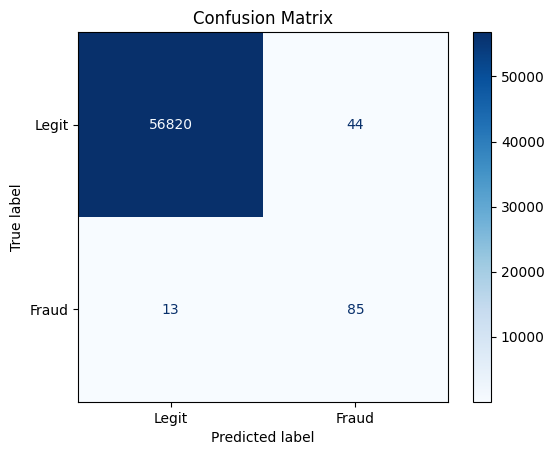

In [6]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
display.plot(cmap = "Blues")
plt.title("Confusion Matrix")
plt.show()

#### ROC Curve

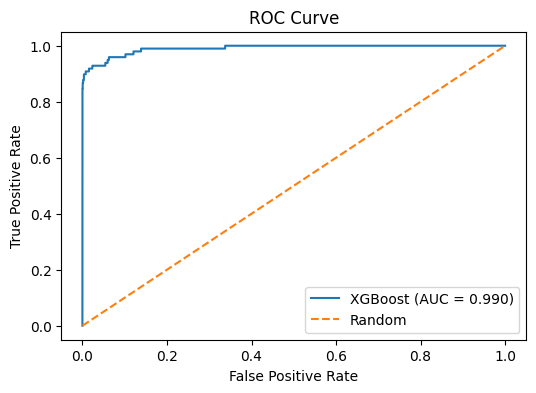

In [7]:
fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_prob)
# fpr = flase positive rate(x-axis), tpr = true positive rate(y-axis)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label = f"XGBoost (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.plot( )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### SHAP Explainability

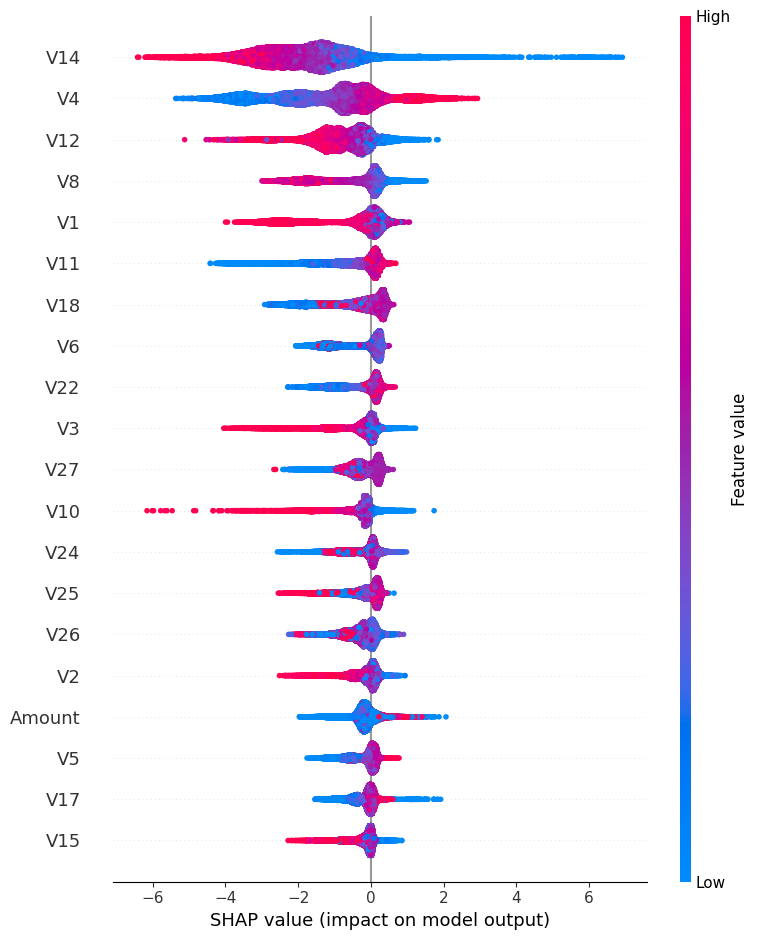

In [8]:
explainer = shap.TreeExplainer(model)
    # prepare explaination tool
shap_values = explainer.shap_values(x_test)
     # shap_values tells how much did each feature contrinute to prediction?
shap.summary_plot(shap_values, x_test)

####  Interpretation
- Low V14 strongly pushes toward fraud. ->low V14 cell_values
- High V14 pushes away from fraud
- Similar for other

#### SHAP plot for a one prediction (single prediction)

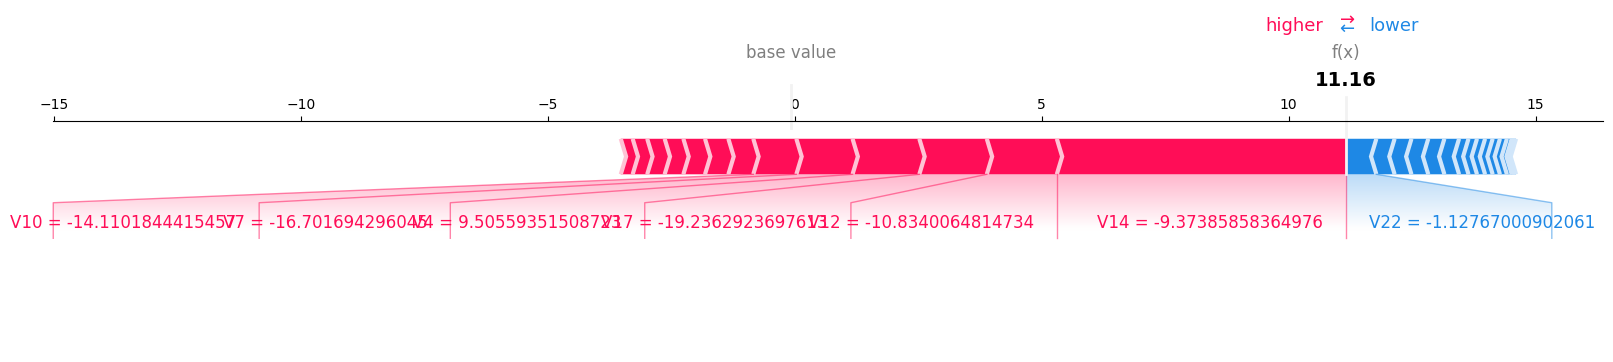

In [11]:
idx = 0   # select first row/sample from test data.
shap.force_plot(
    explainer.expected_value, #avg prediction before seeing any feature ie.base prediction
    shap_values[idx], # shap contributions for that one sample
    x_test.iloc[idx], # gives actual feature values of that row
    matplotlib=True #displays plot using matplotlib instead of javascript
)

#### Interpretation:
-The model starts from a base value and features push the prediction:
- RIGHT → higher prediction
- LEFT → lower prediction


- Red means features pushing prediction HIGHER (likely fraud)
- Blue means features pushing prediction LOWER